###  Architecture 
Here instead of EfficientNet CNN based model, Swin transformer is used to analyze the inclusion of metadata and their interaction to the images. All the hyper parameters kept same except the batch_size to 12 instead of 32 due to heavy computation in swin model.



In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [2]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "extra","exp5_SwinT_StrongAug_MLPHead_mse_Seed50")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp5"]   # define in config
cfg["head_type"] = "mlp"
cfg["name"] = "exp5_SwinT_StrongAug_MLPHead_mse_Seed50"
cfg["loss"] = "mse"
cfg["seed"] = 50
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="fusion",      #  fusion
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      #  fold for each sample
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp5_SwinT_StrongAug_MLPHead_mse_Seed50: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=23.5661 | ValRMSE: 20.3507
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=20.6936 | ValRMSE: 20.3332
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=20.5763 | ValRMSE: 19.4205
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=19.1064 | ValRMSE: 17.9725
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=17.5887 | ValRMSE: 17.7914
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=16.6523 | ValRMSE: 17.9148
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=15.9225 | ValRMSE: 17.5616
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=15.2041 | ValRMSE: 17.8696
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=14.7695 | ValRMSE: 17.7563
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=14.4690 | ValRMSE: 17.8143
Fold 1 best RMSE: 17.5616

=== exp5_SwinT_StrongAug_MLPHead_mse_Seed50: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=23.3310 | ValRMSE: 20.7720
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=20.5768 | ValRMSE: 20.4006
Epoch 3/10 | Fold 2 | Train[MSE]: RMSE=19.4089 | ValRMSE: 18.8549
E

In [4]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")


Fold 1 OOF RMSE: 17.5616 (n=1983)
Fold 2 OOF RMSE: 18.1409 (n=1983)
Fold 3 OOF RMSE: 18.1396 (n=1982)
Fold 4 OOF RMSE: 17.5393 (n=1982)
Fold 5 OOF RMSE: 17.6065 (n=1982)


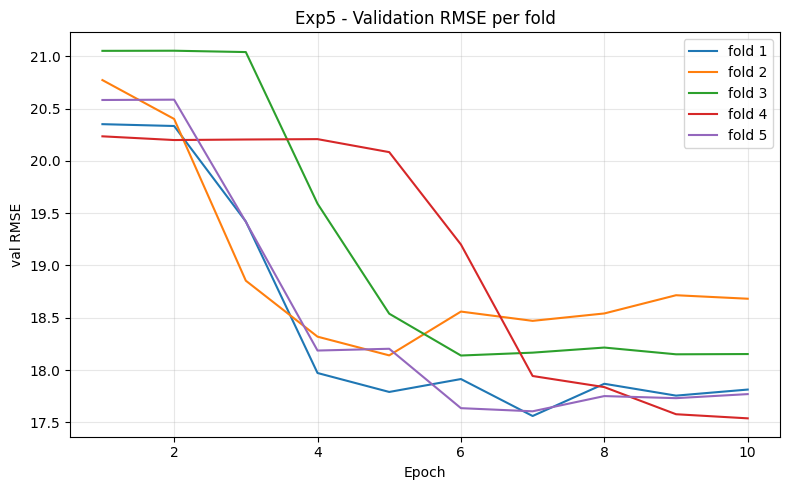

In [5]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp5")

In [6]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,48a66727373de4e7fa7bb3331cd9acc8,2,96,23.418919,72.581081
1,76769dbee1699e04ae1befa3128db7d6,5,100,27.680510,72.319490
2,4435d6f98ad72782ca0cf61f946b016d,2,100,27.948444,72.051556
3,e638853bdec13e6cc76b69f169b34740,4,96,24.966597,71.033403
4,054cef9194f1a4513dc0965893b589bf,5,2,71.356880,69.356880


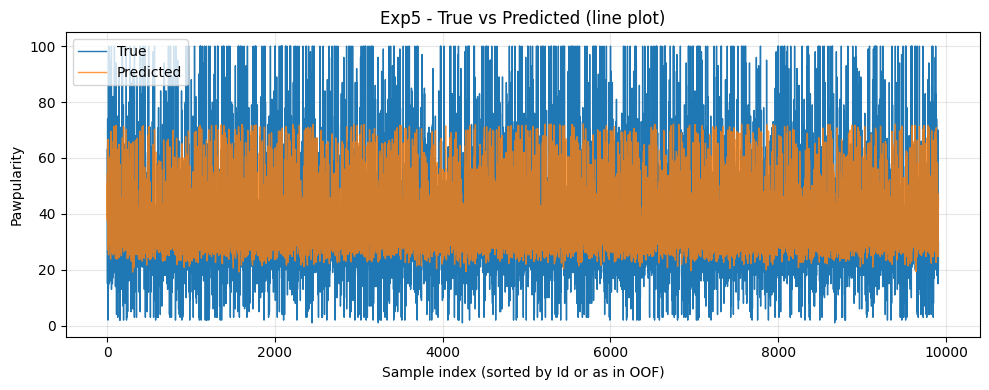

In [7]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="Exp5")





Exp5_Swin_EarlyFusionMLPHead OOF RMSE: 17.60001884040648
Exp5_Swin_EarlyFusionLinearHead OOF RMSE: 17.799802848568795
ΔRMSE (Exp5_Swin_EarlyFusionLinearHead - Exp5_Swin_EarlyFusionMLPHead): 0.19978400816231456


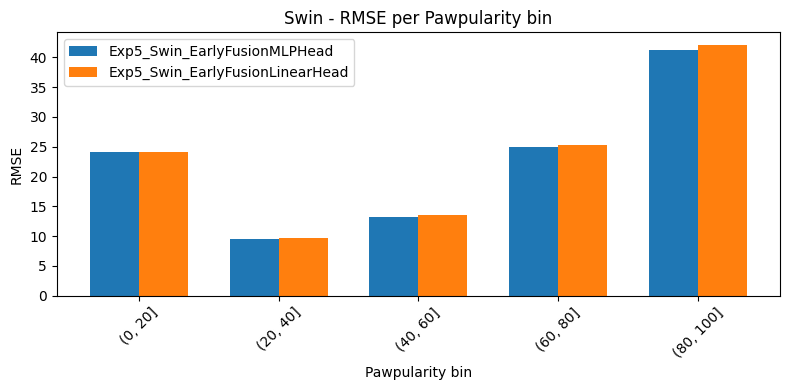

In [8]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../../outputs/exp5/oof_detail.csv",
    oof_path_b=out_dir+"/oof_detail.csv",
    bins=bins,
    label_a="Exp5_Swin_EarlyFusionMLPHead",
    label_b="Exp5_Swin_EarlyFusionLinearHead",
    title_prefix="Swin",
)

In [9]:
df_bins.head()

,bin,count,Exp5_Swin_EarlyFusionMLPHead_rmse,Exp5_Swin_EarlyFusionLinearHead_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.173492,24.043712,-0.129780,Exp5_Swin_EarlyFusionLinearHead_better
1,"(20, 40]",5119,9.572831,9.709950,0.137119,Exp5_Swin_EarlyFusionMLPHead_better
2,"(40, 60]",2088,13.258303,13.538840,0.280537,Exp5_Swin_EarlyFusionMLPHead_better
3,"(60, 80]",727,24.983769,25.212242,0.228473,Exp5_Swin_EarlyFusionMLPHead_better
4,"(80, 100]",561,41.202795,42.088775,0.885980,Exp5_Swin_EarlyFusionMLPHead_better


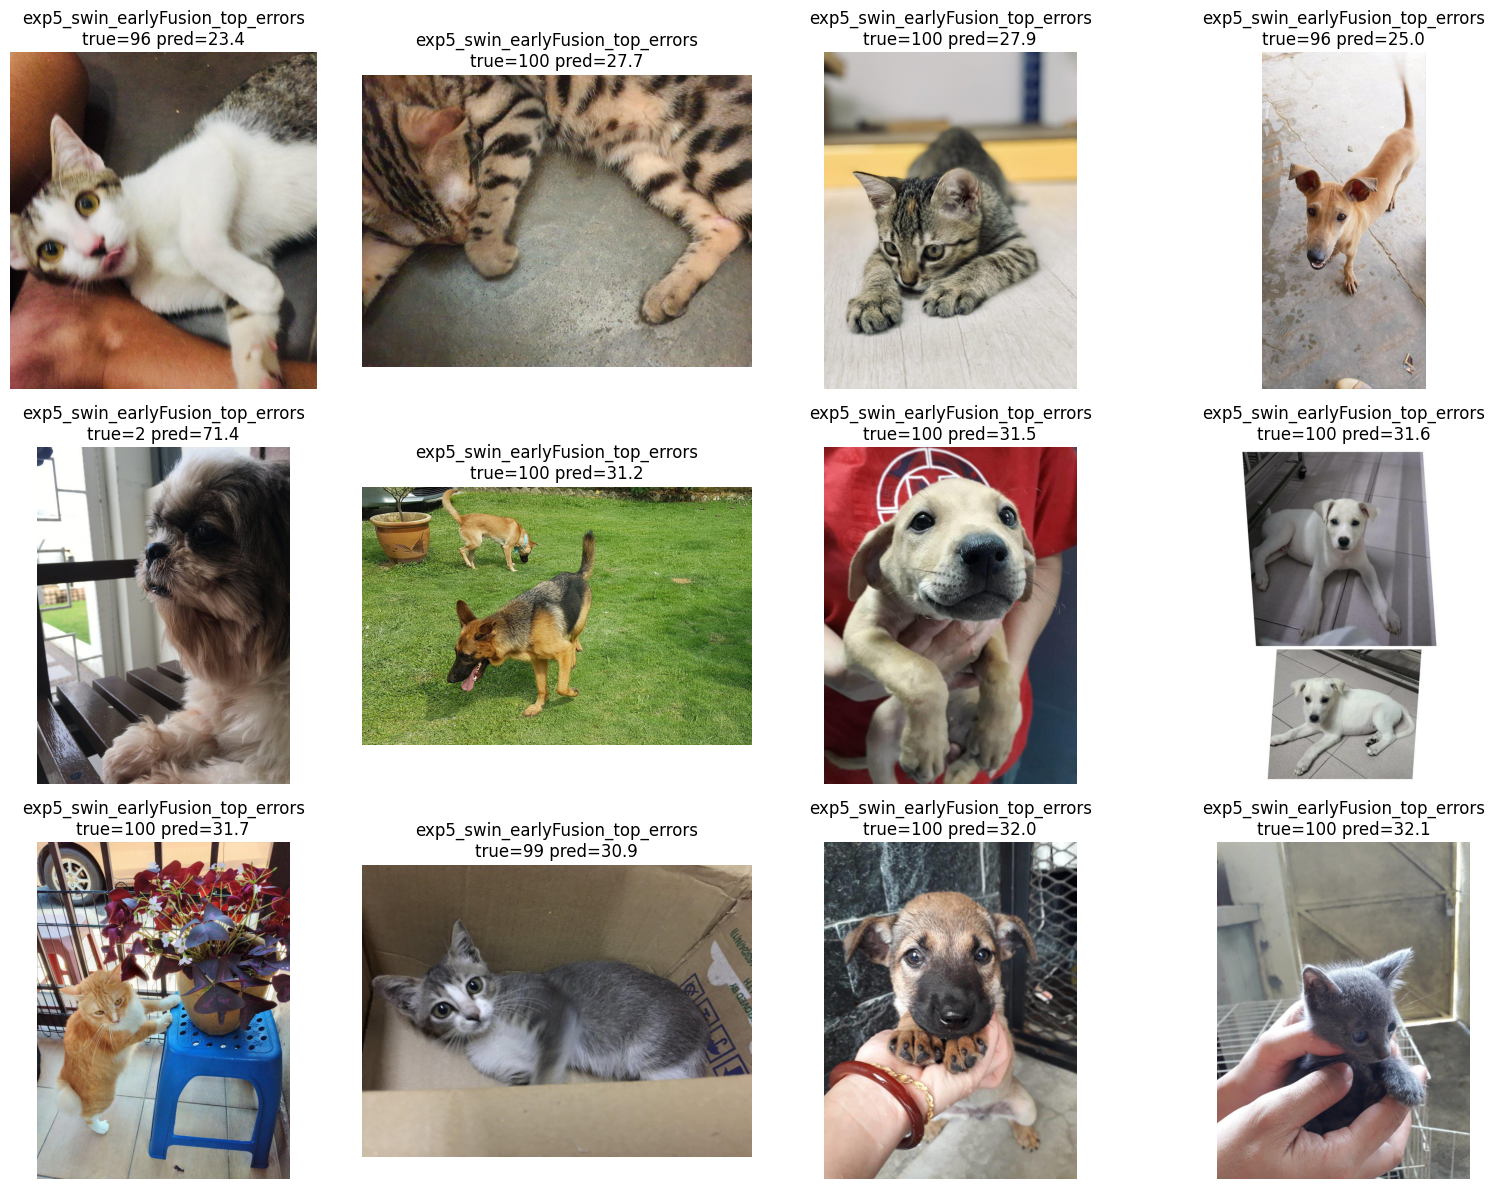

In [10]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp5_swin_earlyFusion_top_errors")

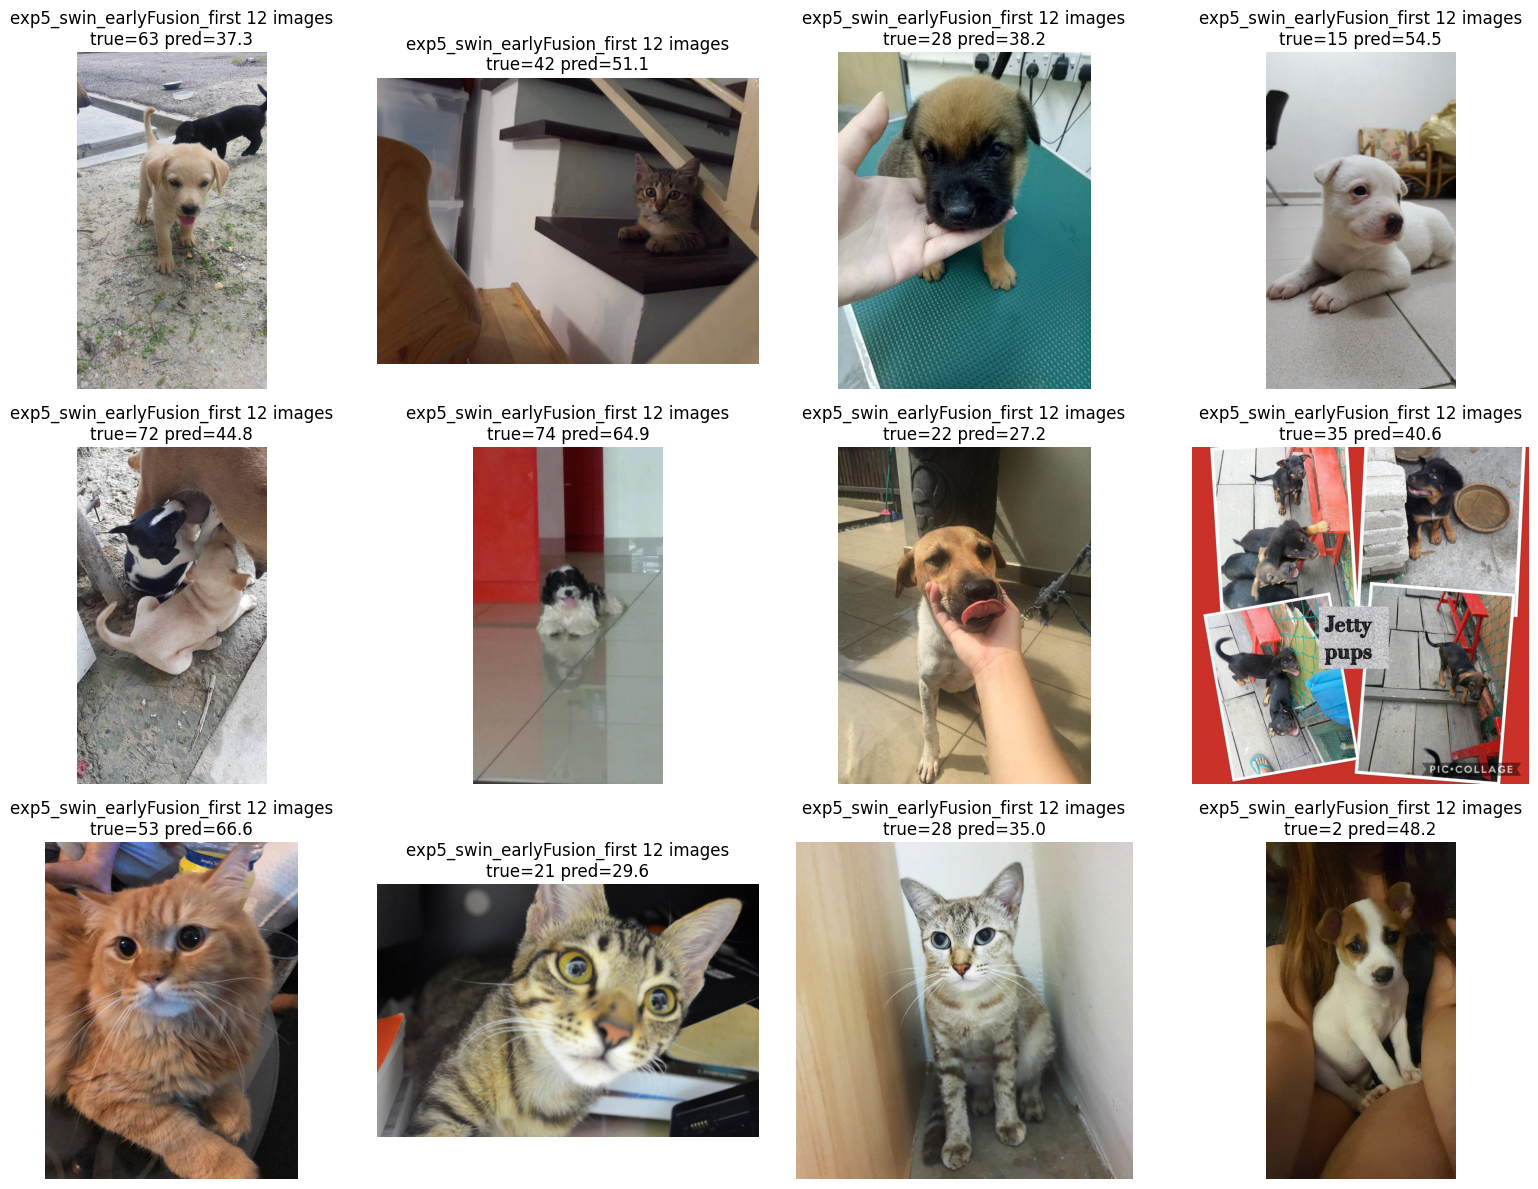

In [11]:

show_images_grid(oof_df, img_folder, n=12, title_prefix="exp5_swin_earlyFusion_first 12 images")